In [15]:
import os, re, math, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio import features, mask
from rasterio.enums import Resampling
from shapely.geometry import shape, Polygon, box
from shapely.ops import unary_union
import geopandas as gpd
from tqdm import tqdm
import pymannkendall as mk
from scipy.stats import linregress
warnings.filterwarnings("ignore")

S2_DIR = r"G:\Mi unidad\GEE_Biweekly_S2"
S1_DIR = r"G:\Mi unidad\GEE_Biweekly_S1"
RESULTS = r".\results"
os.makedirs(RESULTS, exist_ok=True)

# --- filename date parser (expects YYYYMMDD_*.tif)
DATE_RE = re.compile(r"(\d{8})_")
def parse_date(path):
    """Extract YYYYMMDD from filename in any position."""
    fname = os.path.basename(path)
    m = re.search(r"(20\d{6})", fname)  # finds any 8-digit date starting with 20
    if not m:
        raise ValueError(f"Cannot parse date from {path}")
    s = m.group(1)
    return pd.to_datetime(f"{s[:4]}-{s[4:6]}-{s[6:8]}")

# --- load first raster profile (to inherit georeferencing)
def first_profile(folder):
    tif = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])[0]
    with rasterio.open(tif) as src:
        return src.profile

# --- read one band (1-based)
def read_band(path, band=1):
    with rasterio.open(path) as src:
        arr = src.read(band).astype(np.float32)
        nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)
    return arr

# --- write raster
def write_raster(path, profile, array_or_stack):
    prof = profile.copy()
    if array_or_stack.ndim == 2:
        prof.update(count=1, dtype="float32")
        with rasterio.open(path, "w", **prof) as dst:
            dst.write(array_or_stack.astype(np.float32), 1)
    elif array_or_stack.ndim == 3:
        prof.update(count=array_or_stack.shape[0], dtype="float32")
        with rasterio.open(path, "w", **prof) as dst:
            for i in range(array_or_stack.shape[0]):
                dst.write(array_or_stack[i].astype(np.float32), i+1)
    else:
        raise ValueError("Expected 2D or 3D array")


In [16]:
# === Get AOI ===
# Option A (recommended): read your AOI polygons file
# aoi = gpd.read_file(r"G:\Mi unidad\AOI\bofedales_or_pastures.shp").to_crs(32719)

# Option B: derive AOI from valid pixels of first S2 raster (mask polygons you already used)
prof = first_profile(S2_DIR)
with rasterio.open(sorted([os.path.join(S2_DIR,f) for f in os.listdir(S2_DIR) if f.endswith(".tif")])[0]) as src:
    # take NDVI band 1; non-NaN (or > -1) as valid
    ndvi = src.read(1).astype(np.float32)
    if src.nodata is not None:
        mask_valid = (ndvi != src.nodata)
    else:
        mask_valid = ~np.isnan(ndvi)
    shapes = features.shapes(mask_valid.astype(np.uint8), transform=src.transform)
    polys = [shape(geom) for geom, val in shapes if val == 1]
aoi = gpd.GeoDataFrame(geometry=[unary_union(polys)], crs=32719)

# === Build a hex grid (choose ~1 km between parallel sides; adjust to your scale) ===
def hex_grid(aoi_gdf, hex_diameter=750):
    # diameter ~ distance between opposite vertices; compute hex width/height
    w = hex_diameter
    h = math.sqrt(3)/2 * w
    minx, miny, maxx, maxy = aoi_gdf.total_bounds
    cols = int((maxx - minx) / (w*0.75)) + 3
    rows = int((maxy - miny) / h) + 3
    hexes = []
    for r in range(rows):
        for c in range(cols):
            x = minx + c * (w * 0.75)
            y = miny + r * h + (0 if c % 2 == 0 else h/2)
            # regular hex centered at (x,y)
            pts = [(x - w/2, y), (x - w/4, y + h/2), (x + w/4, y + h/2),
                   (x + w/2, y), (x + w/4, y - h/2), (x - w/4, y - h/2)]
            hexes.append(Polygon(pts))
    grid = gpd.GeoDataFrame(geometry=hexes, crs=aoi_gdf.crs)
    grid = gpd.overlay(grid, aoi_gdf, how="intersection")
    grid["hex_id"] = np.arange(len(grid))
    return grid

hexes = hex_grid(aoi, hex_diameter=1000)  # 1 km hexes (change to 500 m if you need finer)
hexes.to_file(os.path.join(RESULTS, "AOI_hexes_1km.geojson"), driver="GeoJSON")


In [17]:
# --- collect files / dates
s2_files = sorted([os.path.join(S2_DIR,f) for f in os.listdir(S2_DIR) if f.endswith(".tif")])
s1_files = sorted([os.path.join(S1_DIR,f) for f in os.listdir(S1_DIR) if f.endswith(".tif")])

def season_label(dt):
    # Nov–Mar season gets label e.g. "2022-23"
    y = dt.year
    if dt.month >= 11:  # Nov/Dec belong to Y-(Y+1)
        return f"{y}-{str((y+1)%100).zfill(2)}"
    elif dt.month <= 3: # Jan–Mar belong to (Y-1)-Y
        return f"{y-1}-{str(y%100).zfill(2)}"
    else:
        return None  # out of season

# --- build seasonal composites for NDVI (band1), NDWI (band5), RVI (S1 band4)
profile = first_profile(S2_DIR)

def seasonal_composite(files, band, valid_months={11,12,1,2,3}):
    # returns dict season -> 2D array (mean of available images)
    buckets = {}
    for f in files:
        dt = parse_date(f)
        if dt.month in valid_months:
            lbl = season_label(dt)
            if lbl:
                arr = read_band(f, band=band)
                if lbl not in buckets:
                    buckets[lbl] = []
                buckets[lbl].append(arr)
    out = {}
    for lbl, lst in buckets.items():
        stack = np.stack(lst)
        out[lbl] = np.nanmean(stack, axis=0)
    return out

ndvi_season = seasonal_composite(s2_files, band=1)
ndwi_season = seasonal_composite(s2_files, band=5)
rvi_season  = seasonal_composite(s1_files, band=4)

# --- write seasonal composites (for traceability)
for lbl, arr in ndvi_season.items():
    write_raster(os.path.join(RESULTS, f"NDVI_{lbl}_NovMar_mean.tif"), profile, arr)
for lbl, arr in ndwi_season.items():
    write_raster(os.path.join(RESULTS, f"NDWI_{lbl}_NovMar_mean.tif"), profile, arr)
for lbl, arr in rvi_season.items():
    write_raster(os.path.join(RESULTS, f"RVI_{lbl}_NovMar_mean.tif"), profile, arr)

# --- Δ maps between seasons: (2023-24 minus 2022-23), (2024-25 minus 2023-24)
def delta(a, b):
    out = a.copy()
    out[:] = np.nan
    out = b - a
    return out

pairs = [("2022-23","2023-24"), ("2023-24","2024-25")]
for a,b in pairs:
    if a in ndvi_season and b in ndvi_season:
        write_raster(os.path.join(RESULTS, f"Delta_NDVI_{b}_minus_{a}.tif"), profile, delta(ndvi_season[a], ndvi_season[b]))
    if a in ndwi_season and b in ndwi_season:
        write_raster(os.path.join(RESULTS, f"Delta_NDWI_{b}_minus_{a}.tif"), profile, delta(ndwi_season[a], ndwi_season[b]))
    if a in rvi_season and b in rvi_season:
        write_raster(os.path.join(RESULTS, f"Delta_RVI_{b}_minus_{a}.tif"), profile, delta(rvi_season[a], rvi_season[b]))

# --- Zonal summaries per hex (mean, 10th pct for risk)
def zonal_stats_array(arr, profile, zones_gdf, stat="mean"):
    # rasterize zone ids
    transform = profile["transform"]
    out_shape = (profile["height"], profile["width"])
    shapes = ((geom, int(i)) for geom, i in zip(zones_gdf.geometry, zones_gdf.hex_id))
    zones = features.rasterize(shapes=shapes, out_shape=out_shape, transform=transform, fill=0)
    df = []
    for hid in zones_gdf.hex_id:
        m = zones == int(hid)
        vals = arr[m]
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            mu, p10 = np.nan, np.nan
        else:
            mu = float(np.mean(vals))
            p10 = float(np.percentile(vals, 10))
        df.append({"hex_id": int(hid), "mean": mu, "p10": p10})
    return pd.DataFrame(df)

# Example: summarize Δ 2023-24 vs 2022-23
def read_delta(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr)
        return arr, src.profile

for metric in ["NDVI","NDWI","RVI"]:
    p = os.path.join(RESULTS, f"Delta_{metric}_2023-24_minus_2022-23.tif")
    if os.path.exists(p):
        arr, prof = read_delta(p)
        zs = zonal_stats_array(arr, prof, hexes)
        zs.to_csv(os.path.join(RESULTS, f"Zonal_{metric}_Delta_2023-24_vs_2022-23_hex1km.csv"), index=False)


In [18]:
def build_stack(files, band):
    """Return 3D array [time, rows, cols] sorted by date, plus profile."""
    files_sorted = sorted(files, key=parse_date)
    with rasterio.open(files_sorted[0]) as src:
        H, W = src.height, src.width
        prof = src.profile
        nodata = src.nodata
    T = len(files_sorted)
    stack = np.full((T, H, W), np.nan, dtype=np.float32)
    dates = []
    for t, f in enumerate(files_sorted):
        dates.append(parse_date(f))
        arr = read_band(f, band=band)
        stack[t] = arr
    return stack, prof, pd.to_datetime(dates)

def mk_sen_cube(stack):
    H, W = stack.shape[1], stack.shape[2]
    slope = np.full((H,W), np.nan, dtype=np.float32)
    zstat = np.full((H,W), np.nan, dtype=np.float32)
    pval  = np.full((H,W), np.nan, dtype=np.float32)
    for i in tqdm(range(H), desc="MK/Sen rows"):
        series = stack[:, i, :]          # [T, W]
        valid_counts = np.sum(~np.isnan(series), axis=0)
        for j in range(W):
            s = series[:, j]
            if np.sum(~np.isnan(s)) < 6:  # need a few points
                continue
            res = mk.original_test(s, alpha=0.1)  # returns trend,z,p, Tau, s, var_s, slope, intercept
            slope[i,j] = res.slope
            zstat[i,j] = res.z
            pval[i,j]  = res.p
    return np.stack([slope, zstat, pval], axis=0)

# OSAVI (band 2), NDWI (band 5) from S2; RVI (band 4) from S1
s2_files = sorted([os.path.join(S2_DIR,f) for f in os.listdir(S2_DIR) if f.endswith(".tif")])
s1_files = sorted([os.path.join(S1_DIR,f) for f in os.listdir(S1_DIR) if f.endswith(".tif")])

for metric, (src_files, band) in {
    "OSAVI": (s2_files, 2),
    "NDWI" : (s2_files, 5),
    "RVI"  : (s1_files, 4),
}.items():
    stack, prof, dates = build_stack(src_files, band)
    out = mk_sen_cube(stack)  # [3, H, W]
    write_raster(os.path.join(RESULTS, f"{metric}_MK_SenSlope_Z_P.tif"), prof, out)

# Optional: create simple masks p<=0.1
for metric in ["OSAVI","NDWI","RVI"]:
    with rasterio.open(os.path.join(RESULTS, f"{metric}_MK_SenSlope_Z_P.tif")) as src:
        slope = src.read(1); z = src.read(2); p = src.read(3)
        mask_sig = (p <= 0.1).astype(np.uint8)
        prof = src.profile.copy(); prof.update(count=1, dtype="uint8")
        with rasterio.open(os.path.join(RESULTS, f"{metric}_sig_p01_mask.tif"), "w", **prof) as dst:
            dst.write(mask_sig, 1)


MK/Sen rows: 100%|██████████| 782/782 [13:22<00:00,  1.03s/it] 


In [36]:
# --- NDVI trend (band 1) from Sentinel-2 bi-weekly files ---
ndvi_files = sorted([os.path.join(S2_DIR, f)
                     for f in os.listdir(S2_DIR)
                     if f.endswith(".tif")])

# Build the NDVI stack and run MK/Sen
stack, prof, dates = build_stack(ndvi_files, band=1)
out = mk_sen_cube(stack)     # returns [3, H, W] → slope, z, p

# Save 3-band raster: slope, z-statistic, p-value
write_raster(os.path.join(RESULTS, "NDVI_MK_SenSlope_Z_P.tif"), prof, out)
print("✅ NDVI MK/Sen trend cube saved")

# --- Create significance mask (p ≤ 0.1) ---
with rasterio.open(os.path.join(RESULTS, "NDVI_MK_SenSlope_Z_P.tif")) as src:
    slope = src.read(1)
    z     = src.read(2)
    p     = src.read(3)
    mask_sig = (p <= 0.1).astype("uint8")
    prof = src.profile.copy()
    prof.update(count=1, dtype="uint8")

    with rasterio.open(os.path.join(RESULTS, "NDVI_sig_p01_mask.tif"), "w", **prof) as dst:
        dst.write(mask_sig, 1)

print("✅ NDVI significance mask saved (p ≤ 0.1)")


MK/Sen rows: 100%|██████████| 782/782 [08:29<00:00,  1.53it/s]


✅ NDVI MK/Sen trend cube saved
✅ NDVI significance mask saved (p ≤ 0.1)


In [20]:
import pandas as pd

# --- Load your raw file (semicolon-separated, Spanish decimal format)
raw_path = r"E:\Hackathon_Picotani_datos_E\Ananea-2022-2026.csv"

# Read with proper separator
df = pd.read_csv(raw_path, sep=';', decimal='.')

# --- Build a proper datetime column
df["date"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes"], day=df["Día"]))

# --- Rename precipitation column
df["precip_mm"] = df["Precipitación (mm)"]

# --- Add station metadata
df["station_id"] = "PUNO_01"
df["lat"] = -14.6763     # 14°40'34.6"S  → -14.6763
df["lon"] = -69.5339     # 69°32'1.88"W  → -69.5339

# --- Keep only what RESTREND code needs
out = df[["station_id","date","precip_mm","lat","lon"]].copy()

# --- Save clean version
out_path = r".\stations_precip.csv"
out.to_csv(out_path, index=False)
print(f"✅ Saved cleaned station file: {out_path}")
print(out.head())


✅ Saved cleaned station file: .\stations_precip.csv
  station_id       date  precip_mm      lat      lon
0    PUNO_01 2022-01-01        8.8 -14.6763 -69.5339
1    PUNO_01 2022-01-02        9.0 -14.6763 -69.5339
2    PUNO_01 2022-01-03        0.0 -14.6763 -69.5339
3    PUNO_01 2022-01-04        1.5 -14.6763 -69.5339
4    PUNO_01 2022-01-05        1.4 -14.6763 -69.5339


In [29]:
# --- Load stations & build seasonal rainfall (Nov–Mar sums)
stations_csv = r"stations_precip.csv"
st = pd.read_csv(stations_csv, parse_dates=["date"])
st["season"] = st["date"].apply(lambda d: f"{d.year}-{str((d.year+1)%100).zfill(2)}" if d.month>=11
                                else (f"{d.year-1}-{str(d.year%100).zfill(2)}" if d.month<=3 else None))
st = st.dropna(subset=["season"])
rain_season = (st.groupby(["station_id","season"], as_index=False)["precip_mm"]
                 .sum().rename(columns={"precip_mm":"rain_mm"}))

# --- pick nearest station per hex
gstations = (st.drop_duplicates(["station_id"])[["station_id","lat","lon"]]
               .rename(columns={"lat":"latitude","lon":"longitude"}))
gstations = gpd.GeoDataFrame(gstations, geometry=gpd.points_from_xy(gstations.longitude, gstations.latitude), crs=4326).to_crs(32719)
hexes_ = hexes.copy()
nearest = gpd.sjoin_nearest(hexes_, gstations[["station_id","geometry"]], how="left")
hex_station = nearest[["hex_id","station_id"]]

# --- build seasonal NDVI per hex (using the composites you wrote)
def zonal_mean_from_raster(raster_path, zones_gdf, id_col="hex_id"):
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr = np.where(arr==src.nodata, np.nan, arr)
        transform = src.transform
        out_shape = (src.height, src.width)
    shapes = ((geom, int(i)) for geom, i in zip(zones_gdf.geometry, zones_gdf[id_col]))
    zones = features.rasterize(shapes=shapes, out_shape=out_shape, transform=transform, fill=0)
    rows = []
    for hid in zones_gdf[id_col]:
        m = zones == int(hid)
        vals = arr[m]
        vals = vals[~np.isnan(vals)]
        rows.append({"hex_id": int(hid), "mean": (float(np.mean(vals)) if vals.size else np.nan)})
    return pd.DataFrame(rows)

ndvi_hex_season = []
for lbl in ["2022-23","2023-24"]:
    p = os.path.join(RESULTS, f"NDVI_{lbl}_NovMar_mean.tif")
    if os.path.exists(p):
        df = zonal_mean_from_raster(p, hexes)
        df["season"] = lbl
        ndvi_hex_season.append(df)
ndvi_hex_season = pd.concat(ndvi_hex_season, ignore_index=True)

# --- attach rainfall by nearest station
rain_hex = (hex_station.merge(rain_season, on="station_id", how="left")
                       .drop(columns=["station_id"]))

data = (ndvi_hex_season.merge(rain_hex, on=["hex_id","season"], how="left"))

# --- RESTREND per hex: NDVI ~ Rain; collect slope of residual trend (MK)
rows = []
for hid, grp in data.groupby("hex_id"):
    grp = grp.dropna(subset=["mean","rain_mm"])
    if len(grp) < 2:
        continue
    x = grp["rain_mm"].values
    y = grp["mean"].values
    slope, intercept, r, p, se = linregress(x, y)
    yhat = intercept + slope * x
    resid = y - yhat
    # Mann-Kendall on residuals
    mkres = mk.original_test(resid)
    rows.append({
        "hex_id": int(hid),
        "beta_rain_to_ndvi": float(slope),
        "mk_resid_trend": mkres.trend,   # 'increasing','decreasing','no trend'
        "mk_resid_z": float(mkres.z),
        "mk_resid_p": float(mkres.p),
        "mean_resid": float(np.mean(resid))
    })

retrend = pd.DataFrame(rows)
retrend.to_csv(os.path.join(RESULTS, "RESTREND_hex1km_NDVI_vs_Rain.csv"), index=False)


In [33]:
# 1) Build bi-weekly windows from your S2 filenames
s2_files = sorted([os.path.join(S2_DIR,f) for f in os.listdir(S2_DIR) if f.endswith(".tif")],
                  key=parse_date)
# map each file to its 14-day window label
def window_label(dt, start=None, step_days=14):
    start = pd.to_datetime("2022-11-01") if start is None else start
    k = ((dt - start).days) // step_days
    ws = start + pd.Timedelta(days=14*k)
    we = ws + pd.Timedelta(days=14)
    return f"{ws.date()}_{we.date()}"

file_windows = {f: window_label(parse_date(f)) for f in s2_files
                if parse_date(f).month in [11,12,1,2,3]}

# 2) Per hex and per window: NDVI mean from raster
def zonal_from_many(files_by_win, zones_gdf, band=1):
    rows = []
    for win, files in files_by_win.items():
        # mean of available images in the window
        # read & average
        arrs = []
        prof = None
        for f in files:
            with rasterio.open(f) as src:
                a = src.read(band).astype(np.float32)
                if src.nodata is not None:
                    a = np.where(a==src.nodata, np.nan, a)
                arrs.append(a)
                if prof is None: prof = src.profile
        if not arrs: 
            continue
        arr = np.nanmean(np.stack(arrs), axis=0)

        # rasterize hex ids
        zones = features.rasterize(
            [(geom, int(i)) for geom, i in zip(zones_gdf.geometry, zones_gdf.hex_id)],
            out_shape=(prof["height"], prof["width"]), transform=prof["transform"], fill=0
        )
        for hid in zones_gdf.hex_id:
            m = zones == int(hid)
            vals = arr[m]; vals = vals[~np.isnan(vals)]
            rows.append({"hex_id": int(hid), "window": win,
                         "ndvi": float(np.mean(vals)) if vals.size else np.nan})
    return pd.DataFrame(rows)

# group files by window
from collections import defaultdict
files_by_win = defaultdict(list)
for f, w in file_windows.items(): files_by_win[w].append(f)

ndvi_bw = zonal_from_many(files_by_win, hexes, band=1)  # NDVI per hex per bi-weekly window

# 3) Bi-weekly rainfall from station CSV aligned to the same windows
st = pd.read_csv(stations_csv, parse_dates=["date"])
st["window"] = st["date"].apply(lambda d: window_label(d))
rain_bw = (st.groupby(["station_id","window"], as_index=False)["precip_mm"]
             .sum().rename(columns={"precip_mm":"rain_mm"}))

# nearest station per hex (you already computed hex_station)
rain_hex_bw = (hex_station.merge(rain_bw, on="station_id", how="left")
                        .drop(columns=["station_id"]))

# 4) Merge and run RESTREND at bi-weekly scale
bw = (ndvi_bw.merge(rain_hex_bw, on=["hex_id","window"], how="left")
            .dropna(subset=["ndvi","rain_mm"]))

rows = []
for hid, grp in bw.groupby("hex_id"):
    grp = grp.sort_values("window")
    if len(grp) < 6:  # need several time points
        continue
    x = grp["rain_mm"].values
    y = grp["ndvi"].values
    slope, intercept, *_ = linregress(x, y)
    resid = y - (intercept + slope * x)
    mkres = mk.original_test(resid, alpha=0.1)
    rows.append({
        "hex_id": int(hid),
        "beta_rain_to_ndvi": float(slope),
        "mk_resid_trend": mkres.trend,
        "mk_resid_z": float(mkres.z),
        "mk_resid_p": float(mkres.p),
        "resid_mean": float(np.mean(resid)),
        "n_windows": int(len(grp))
    })

retrend_bw = pd.DataFrame(rows)
retrend_bw.to_csv(os.path.join(RESULTS, "RESTREND_hex1km_biweekly_NDVI_vs_Rain.csv"), index=False)


                                            geometry  hex_id
0  POLYGON ((413042.5 8388704.76, 413126.077 8388...       0
1  POLYGON ((413230 8389029.519, 413330 8389029.5...       1
2  POLYGON ((414355 8389029.519, 414730 8389029.5...       2
3  POLYGON ((414917.5 8388704.76, 415120 8388704....       3
4  POLYGON ((412480 8389679.038, 412667.5 8389354...       4


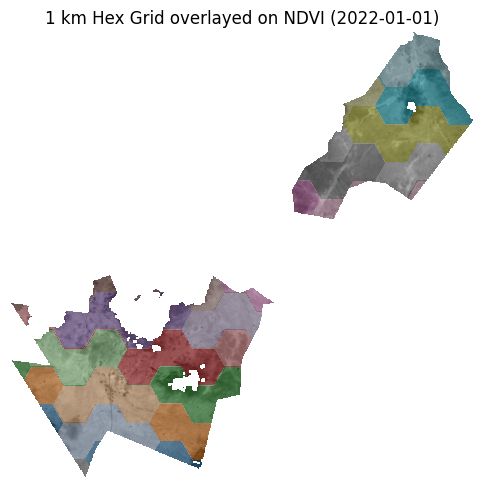

In [12]:
import math
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon
from shapely.ops import unary_union
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# === Input Sentinel-2 file ===
src_path = r"G:\Mi unidad\GEE_Biweekly_S2\20220101_S2_Indices.tif"

# === Read the raster and build a mask of valid pixels ===
with rasterio.open(src_path) as src:
    ndvi = src.read(1).astype(float)
    mask_valid = ndvi > -10  # quick filter for real pixels
    transform = src.transform
    profile = src.profile

# === Convert valid pixels to a polygon (AOI) ===
shapes = features.shapes(mask_valid.astype(np.uint8), transform=transform)
polys = [shape(geom) for geom, val in shapes if val == 1]
aoi = gpd.GeoDataFrame(geometry=[unary_union(polys)], crs=src.crs)

# === Build 1 km hex grid ===
def hex_grid(aoi_gdf, hex_diameter=1000):
    w = hex_diameter
    h = math.sqrt(3)/2 * w
    minx, miny, maxx, maxy = aoi_gdf.total_bounds
    cols = int((maxx - minx) / (w*0.75)) + 3
    rows = int((maxy - miny) / h) + 3
    hexes = []
    for r in range(rows):
        for c in range(cols):
            x = minx + c * (w * 0.75)
            y = miny + r * h + (0 if c % 2 == 0 else h/2)
            pts = [(x - w/2, y), (x - w/4, y + h/2), (x + w/4, y + h/2),
                   (x + w/2, y), (x + w/4, y - h/2), (x - w/4, y - h/2)]
            hexes.append(Polygon(pts))
    grid = gpd.GeoDataFrame(geometry=hexes, crs=aoi_gdf.crs)
    grid = gpd.overlay(grid, aoi_gdf, how="intersection")
    grid["hex_id"] = np.arange(len(grid))
    return grid

hexes = hex_grid(aoi, hex_diameter=750)  # 1 km
print(hexes.head())

# === Rasterize the hex IDs ===
hex_raster = features.rasterize(
    [(geom, int(i)) for geom, i in zip(hexes.geometry, hexes.hex_id)],
    out_shape=(profile["height"], profile["width"]),
    transform=profile["transform"],
    fill=0,
    dtype="int32"
)

# === Save it as a GeoTIFF (to open in QGIS or overlay on NDVI) ===
profile.update(count=1, dtype="int32")
with rasterio.open("hex_grid_1km.tif", "w", **profile) as dst:
    dst.write(hex_raster, 1)

# === Quick visualization ===
plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap="gray", vmin=0, vmax=1)
plt.imshow(np.ma.masked_where(hex_raster==0, hex_raster), alpha=0.4, cmap="tab20")
plt.title("1 km Hex Grid overlayed on NDVI (2022-01-01)")
plt.axis("off")
plt.show()